In [1]:
import joblib

preprocessor = joblib.load("../models/preprocessor.pkl")
random_forest = joblib.load("../models/random_forest.pkl")

print("Models loaded successfully!")

Models loaded successfully!


In [2]:
random_forest = joblib.load("../models/random_forest.pkl")

print("Random Forest loaded!")

Random Forest loaded!


In [3]:
import pandas as pd

df = pd.read_csv("../data/processed/churn_cleaned.csv")

print("Shape:", df.shape)
print(df.head())

Shape: (7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies   

In [7]:
import pandas as pd

# Load cleaned data
df = pd.read_csv("../data/processed/churn_cleaned.csv")

# Standardize column names
df.columns = df.columns.str.strip().str.lower()

print("Columns:")
print(df.columns.tolist())

print("\nShape:")
print(df.shape)

# Target
y = df["churn"]

# Features
X = df.drop(columns=["churn"])

print("\nX shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

Columns:
['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents', 'tenure', 'phoneservice', 'multiplelines', 'internetservice', 'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling', 'paymentmethod', 'monthlycharges', 'totalcharges', 'churn']

Shape:
(7043, 21)

X shape: (7043, 20)
y shape: (7043,)

Target distribution:
churn
No     5174
Yes    1869
Name: count, dtype: int64


In [9]:
# Encode churn target
y = y.map({"No": 0, "Yes": 1})

print("Target distribution:")
print(y.value_counts())

print("\nTarget dtype:", y.dtype)

Target distribution:
churn
0    5174
1    1869
Name: count, dtype: int64

Target dtype: int64


In [8]:
print(df.columns.tolist())

['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents', 'tenure', 'phoneservice', 'multiplelines', 'internetservice', 'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling', 'paymentmethod', 'monthlycharges', 'totalcharges', 'churn']


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (5634, 20)
X_test : (1409, 20)
y_train: (5634,)
y_test : (1409,)


In [11]:
X_test_processed = preprocessor.transform(X_test)

print("Processed X_test:", X_test_processed.shape)

Processed X_test: (1409, 45)


In [12]:
print("Processed X_test shape:", X_test_processed.shape)
print("Random Forest expects:", random_forest.n_features_in_)

Processed X_test shape: (1409, 45)
Random Forest expects: 45


In [13]:
y_pred = random_forest.predict(X_test_processed)
y_prob = random_forest.predict_proba(X_test_processed)[:, 1]

print("Predictions generated successfully!")
print("Prediction shape:", y_pred.shape)
print("Probability shape:", y_prob.shape)

Predictions generated successfully!
Prediction shape: (1409,)
Probability shape: (1409,)


c:\Users\Isha\OneDrive\Desktop\customer-churn-analysis\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\Isha\OneDrive\Desktop\customer-churn-analysis\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [15]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall   :", round(recall_score(y_test, y_pred), 4))
print("F1 Score :", round(f1_score(y_test, y_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob), 4))

Accuracy : 0.7573
Precision: 0.5295
Recall   : 0.7674
F1 Score : 0.6266
ROC-AUC  : 0.8393


Confusion Matrix:
[[780 255]
 [ 87 287]]

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.90      0.75      0.82      1035
       Churn       0.53      0.77      0.63       374

    accuracy                           0.76      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.76      0.77      1409



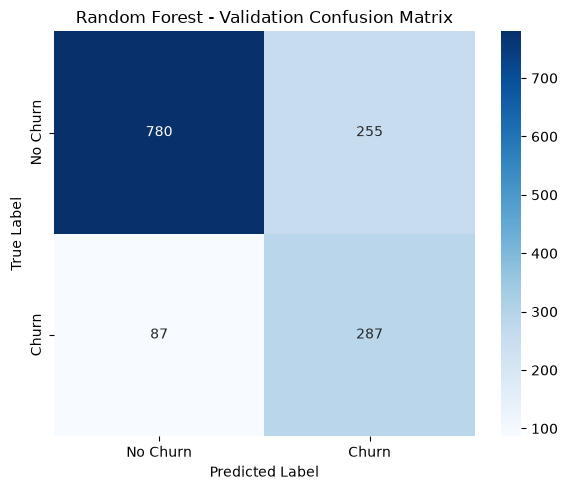

In [16]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

# Classification Report
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["No Churn", "Churn"]
))

# Plot Confusion Matrix
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Random Forest - Validation Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

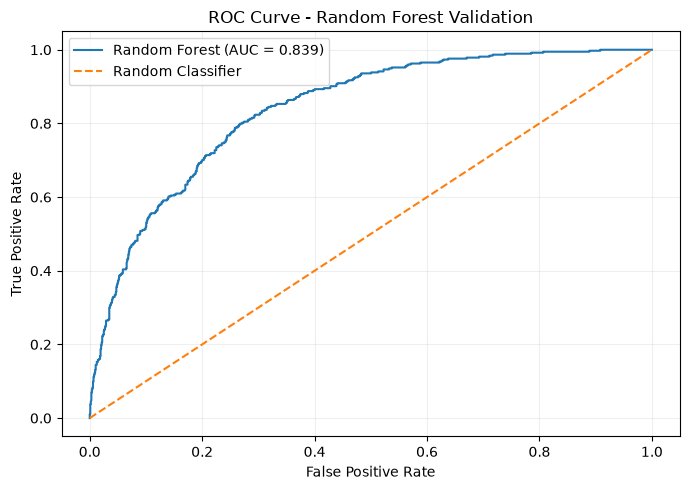

In [17]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculate AUC
auc_score = roc_auc_score(y_test, y_prob)

# Plot ROC Curve
plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Random Forest (AUC = {auc_score:.3f})"
)

# Random classifier baseline
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest Validation")

plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [18]:
# Generate churn probabilities

churn_probability = random_forest.predict_proba(X_test_processed)[:, 1]

print("Churn probability generated successfully!")
print("Number of customers:", len(churn_probability))
print("\nFirst 10 probabilities:")
print(churn_probability[:10])

Churn probability generated successfully!
Number of customers: 1409

First 10 probabilities:
[0.01814284 0.83331556 0.09767646 0.49181321 0.04826055 0.77563182
 0.54683428 0.24531402 0.00787576 0.60791084]


c:\Users\Isha\OneDrive\Desktop\customer-churn-analysis\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [19]:
# Create churn risk categories

def classify_risk(probability):
    if probability >= 0.70:
        return "High Risk"
    elif probability >= 0.40:
        return "Medium Risk"
    else:
        return "Low Risk"


risk_category = pd.Series(churn_probability).apply(classify_risk)

print("Risk distribution:")
print(risk_category.value_counts())

Risk distribution:
Low Risk       770
Medium Risk    333
High Risk      306
Name: count, dtype: int64


In [20]:
# Get original customer information for the test set

customer_results = df.loc[X_test.index].copy()

customer_results["churn_probability"] = churn_probability
customer_results["predicted_churn"] = y_pred
customer_results["risk_category"] = risk_category.values

print(customer_results.head())

      customerid  gender  seniorcitizen partner dependents  tenure  \
437   4376-KFVRS    Male              0     Yes        Yes      72   
2280  2754-SDJRD  Female              1      No         No       8   
2235  9917-KWRBE  Female              0     Yes        Yes      41   
4460  0365-GXEZS    Male              0     Yes         No      18   
3761  9385-NXKDA  Female              0     Yes         No      72   

     phoneservice multiplelines internetservice onlinesecurity  ...  \
437           Yes           Yes     Fiber optic            Yes  ...   
2280          Yes           Yes     Fiber optic             No  ...   
2235          Yes           Yes             DSL            Yes  ...   
4460          Yes            No     Fiber optic             No  ...   
3761          Yes           Yes             DSL            Yes  ...   

     streamingmovies        contract paperlessbilling  \
437              Yes        Two year              Yes   
2280             Yes  Month-to-month  

In [21]:
def retention_recommendation(risk):
    if risk == "High Risk":
        return "Immediate retention offer"
    elif risk == "Medium Risk":
        return "Personalized engagement"
    else:
        return "Maintain regular engagement"


customer_results["retention_recommendation"] = (
    customer_results["risk_category"]
    .apply(retention_recommendation)
)

print(
    customer_results[
        [
            "customerid",
            "churn_probability",
            "risk_category",
            "retention_recommendation"
        ]
    ].head(10)
)

      customerid  churn_probability risk_category     retention_recommendation
437   4376-KFVRS           0.018143      Low Risk  Maintain regular engagement
2280  2754-SDJRD           0.833316     High Risk    Immediate retention offer
2235  9917-KWRBE           0.097676      Low Risk  Maintain regular engagement
4460  0365-GXEZS           0.491813   Medium Risk      Personalized engagement
3761  9385-NXKDA           0.048261      Low Risk  Maintain regular engagement
5748  4686-UXDML           0.775632     High Risk    Immediate retention offer
3568  2227-JRSJX           0.546834   Medium Risk      Personalized engagement
2976  4830-FAXFM           0.245314      Low Risk  Maintain regular engagement
5928  1830-IPXVJ           0.007876      Low Risk  Maintain regular engagement
1639  4690-LLKUA           0.607911   Medium Risk      Personalized engagement


In [22]:
import os

os.makedirs("../data/processed", exist_ok=True)

customer_results.to_csv(
    "../data/processed/churn_predictions.csv",
    index=False
)

print("Customer churn predictions saved successfully!")

Customer churn predictions saved successfully!


In [23]:
# Create final dashboard dataset

dashboard_df = customer_results.copy()

# Add readable churn labels
dashboard_df["actual_churn_label"] = dashboard_df["churn"].map({
    0: "No Churn",
    1: "Churn"
})

dashboard_df["predicted_churn_label"] = dashboard_df["predicted_churn"].map({
    0: "No Churn",
    1: "Churn"
})

# Convert probability to percentage
dashboard_df["churn_probability_pct"] = (
    dashboard_df["churn_probability"] * 100
).round(2)

# Check final columns
print("Dashboard dataset shape:", dashboard_df.shape)
print("\nColumns:")
print(dashboard_df.columns.tolist())

Dashboard dataset shape: (1409, 28)

Columns:
['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents', 'tenure', 'phoneservice', 'multiplelines', 'internetservice', 'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling', 'paymentmethod', 'monthlycharges', 'totalcharges', 'churn', 'churn_probability', 'predicted_churn', 'risk_category', 'retention_recommendation', 'actual_churn_label', 'predicted_churn_label', 'churn_probability_pct']


In [24]:
dashboard_df.to_csv(
    "../data/processed/churn_dashboard.csv",
    index=False
)

print("Dashboard dataset saved successfully!")

Dashboard dataset saved successfully!
